# 03 — Phase Portraits and Hamiltonian Structure

Visualise the 2D phase space of the acceleration system. Compare Duffing vs Bessel in monostable, weakly bistable, and strongly bistable regimes.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

from steering.params import ModelParams, ForcingParams
from steering.models import (
    DuffingModel,
    BesselSteeringModel,
    ContinuousPFLModel,
    DiscretePFLModel,
    FullCircuitModel,
)
from steering.dynamics import VelocityDynamics, AccelerationDynamics
from steering.integrator import Simulation
from steering.visualization.style import use_paper_style

use_paper_style()


In [20]:
from steering.visualization.phase_portrait import plot_phase_portrait
from steering.analysis.fixed_points import find_fixed_points_2d

params_sets = [
    ('monostable',  ModelParams(kappa_h=1.0, kappa_g=1.0, delta=1.0)),
    ('weak bistable', ModelParams(kappa_h=1.0, kappa_g=1.0, delta=1.49)),
    ('strong bistable', ModelParams(kappa_h=2.0, kappa_g=2.0, delta=1.55)),
]


## Print c1, c3, theta_max for each regime

In [21]:
bessel = BesselSteeringModel()
for name, p in params_sets:
    c1, c3 = bessel.taylor_coefficients(p)
    tmax = np.sqrt(2 * c1 / abs(c3)) if (c1 > 0 and c3 < 0) else float('nan')
    print(f'{name:<18}: c1={c1:+.3f}  c3={c3:+.3f}  theta_max={tmax:.3f}')


monostable        : c1=-14.996  c3=+2.034  theta_max=nan
weak bistable     : c1=+0.181  c3=-1.312  theta_max=0.525
strong bistable   : c1=+63.246  c3=-46.411  theta_max=1.651


## Phase portraits: Duffing vs Bessel, undamped

Hamiltonian level sets in light blue; saddle separatrices in black; fixed points marked.

In [22]:
params_sets

[('monostable',
  ModelParams(kappa_h=1.0, kappa_g=1.0, delta=1.0, Delta_pop=1.1780972450961724, S=1.0, A=1.0, W_D3=0.0, Delta_pop_pfl2=3.141592653589793, N_neurons=None, nonlinearity='quadratic', nonlinearity_params={}, nonlinearity_pfl2=None)),
 ('weak bistable',
  ModelParams(kappa_h=1.0, kappa_g=1.0, delta=1.49, Delta_pop=1.1780972450961724, S=1.0, A=1.0, W_D3=0.0, Delta_pop_pfl2=3.141592653589793, N_neurons=None, nonlinearity='quadratic', nonlinearity_params={}, nonlinearity_pfl2=None)),
 ('strong bistable',
  ModelParams(kappa_h=2.0, kappa_g=2.0, delta=1.55, Delta_pop=1.1780972450961724, S=1.0, A=1.0, W_D3=0.0, Delta_pop_pfl2=3.141592653589793, N_neurons=None, nonlinearity='quadratic', nonlinearity_params={}, nonlinearity_pfl2=None))]

c1=63.246, c3=-46.411, theta_max(Duffing)=1.651


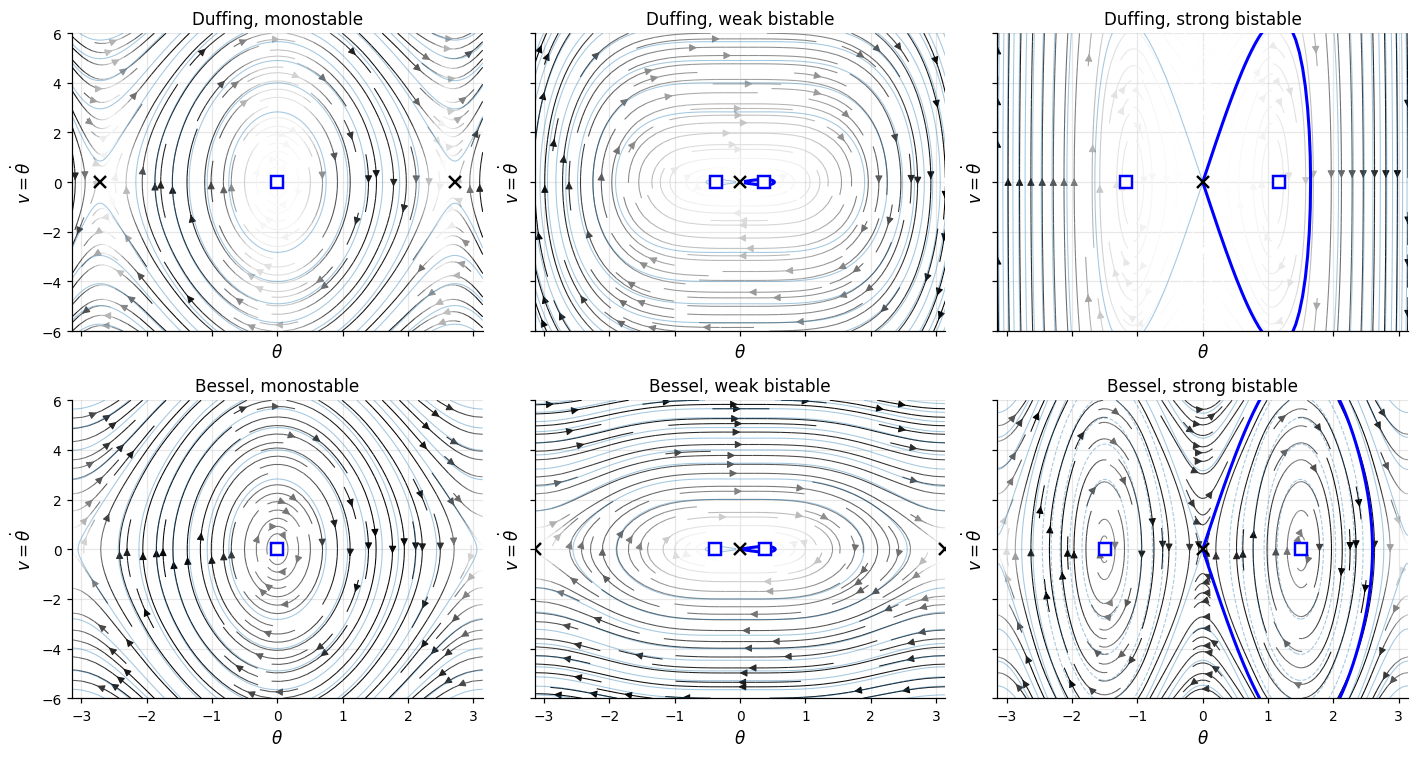

In [23]:
from steering.analysis.homoclinic import numerical_homoclinic
bessel = BesselSteeringModel()


print(f'c1={c1:.3f}, c3={c3:.3f}, theta_max(Duffing)={(2*c1/abs(c3))**0.5:.3f}')

fig, axes = plt.subplots(2, 3, figsize=(13, 7), sharex=True, sharey=True)
for j, (name, p) in enumerate(params_sets):

    duff = DuffingModel.from_params(p)
    for i, (label, model) in enumerate([('Duffing', duff), ('Bessel', bessel)]):
        dyn = AccelerationDynamics(model=model, gamma=0.0, topology='planar')
        plot_phase_portrait(
            dyn, p, theta_range=(-np.pi, np.pi), v_range=(-6, 6),
            n_grid=12, n_contours=12, ax=axes[i, j], overlay_separatrix = False,
        )

        axes[i, j].set_title(f'{label}, {name}')
        if j != 0: 
            if i == 0: 
                c1, c3 = bessel.taylor_coefficients(p)
                duff = DuffingModel(c1=c1, c3=c3)
                t = np.linspace(-6, 6, 1201)
                th_d, v_d = duff.homoclinic_orbit(t)
                axes[i, j].plot(th_d, v_d, 'blue', lw=2)
            else: 
                t_b, th_b, v_b = numerical_homoclinic(bessel, p)
                axes[i, j].plot(th_b, v_b, 'blue', lw=2)
fig.tight_layout(); plt.show()


## Damped trajectories

Add $\gamma = 0.1$ and overlay several initial-condition trajectories — they spiral into the stable foci.

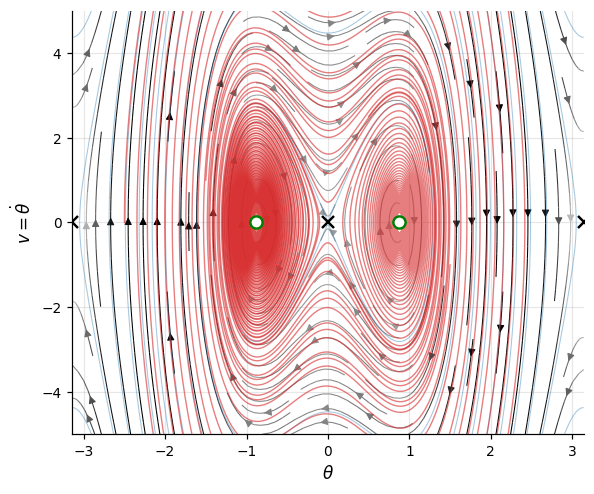

In [5]:
p = ModelParams(kappa_h=2.0, kappa_g=2.0, delta=1.4)
dyn = AccelerationDynamics(model=bessel, gamma=0.1)
sim = Simulation(dyn, p)
fig, ax = plt.subplots(figsize=(6, 5))
plot_phase_portrait(dyn, p, theta_range=(-np.pi, np.pi),
                    v_range=(-5, 5), n_grid=18, n_contours=10,
                    overlay_separatrix=False, ax=ax)
for ic in [(-1.5, 1.0), (1.5, -1.0), (-2.5, 0.0), (0.5, 2.5)]:
    res = sim.run(np.array(ic), (0.0, 60.0))
    ax.plot(res.states[:, 0], res.states[:, 1], 'C3-', lw=0.9, alpha=0.6)
ax.set_xlim(-np.pi, np.pi); ax.set_ylim(-5, 5)
plt.show()
